# 14 — Country Universe Exploration

Before building country-level factor portfolios (analogous to our industry-level pipeline), we need to thoroughly understand the country dimension of our EM universe:

1. **How many countries do we have, and how many stocks per country?**
2. **How does country coverage evolve over time?** (entries, exits, structural breaks)
3. **Which countries have enough stocks for meaningful cross-sectional factor selection?**
4. **How do countries compare to industries as a grouping dimension?**
5. **What are the return and risk characteristics at the country level?**

This analysis will determine whether country-level portfolios are feasible and how to handle small countries.

In [1]:
import os
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

from src.data_loader import load_signal_data, FACTOR_COLUMNS, INDUSTRIES

FIG_DIR = "../output/figures"
CSV_DIR = "../output/csv"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

df = load_signal_data("../data")
print(f"Total obs: {len(df):,}")
print(f"Unique stocks: {df['ric'].nunique()}")
print(f"Unique countries: {df['country'].nunique()}")
print(f"Unique industries: {df['industry'].nunique()}")
print(f"Factor columns (reference): {FACTOR_COLUMNS}")
print(f"Industry universe (n={len(INDUSTRIES)}): {INDUSTRIES}")
print(f"Date range: {df['ym'].min():%Y-%m} to {df['ym'].max():%Y-%m}")

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Total obs: 98,742
Unique stocks: 953
Unique countries: 36
Unique industries: 11
Factor columns (reference): ['log_mktcap', 'pb_w', 'roe_w', 'mom_11m_w', 'ret_vol_w', 'div_yield_w']
Industry universe (n=11): ['BMATR', 'CODIS', 'COSTP', 'ENEGY', 'FINAN', 'HLTHC', 'INDUS', 'RLEST', 'TECNO', 'TELCM', 'UTILS']
Date range: 2004-01 to 2025-03


## 1. Country Overview: Stock Counts and Market Cap

In [2]:
# Summary table: unique stocks, avg stocks/month, avg market cap, date range
ctry_summary = (
    df.groupby("country")
    .agg(
        unique_stocks=("ric", "nunique"),
        total_obs=("ric", "count"),
        avg_mktcap=("mktcap_m", "mean"),
        median_mktcap=("mktcap_m", "median"),
        first_date=("ym", "min"),
        last_date=("ym", "max"),
    )
    .sort_values("unique_stocks", ascending=False)
)

monthly_counts = (
    df.groupby(["ym", "country"])["ric"].nunique().reset_index(name="n_stocks")
)
avg_monthly = monthly_counts.groupby("country")["n_stocks"].agg(
    ["mean", "median", "min", "max"]
).round(1)
avg_monthly.columns = [
    "avg_stocks_mo",
    "median_stocks_mo",
    "min_stocks_mo",
    "max_stocks_mo",
]

ctry_summary = ctry_summary.join(avg_monthly)
ctry_summary["avg_mktcap"] = ctry_summary["avg_mktcap"].round(0)
ctry_summary["median_mktcap"] = ctry_summary["median_mktcap"].round(0)

print("=" * 100)
print("COUNTRY UNIVERSE SUMMARY")
print("=" * 100)
print(ctry_summary.to_string())
print(f"\nTotal countries: {len(ctry_summary)}")

COUNTRY UNIVERSE SUMMARY
                      unique_stocks  total_obs   avg_mktcap  median_mktcap first_date  last_date  avg_stocks_mo  median_stocks_mo  min_stocks_mo  max_stocks_mo
country                                                                                                                                                        
CHINA                           191      15639     184939.0        51262.0 2004-01-01 2025-03-01           61.3              54.0             21            111
SOUTH KOREA                     115      13533   16116356.0      8591113.0 2004-01-01 2025-03-01           53.1              54.0             39             65
INDIA                           107       9387    1576514.0       981034.0 2004-01-01 2025-03-01           45.3              41.0              1             89
TAIWAN                           96      13818     372429.0       184465.0 2004-01-01 2025-03-01           54.2              52.0             44             72
BRAZIL         

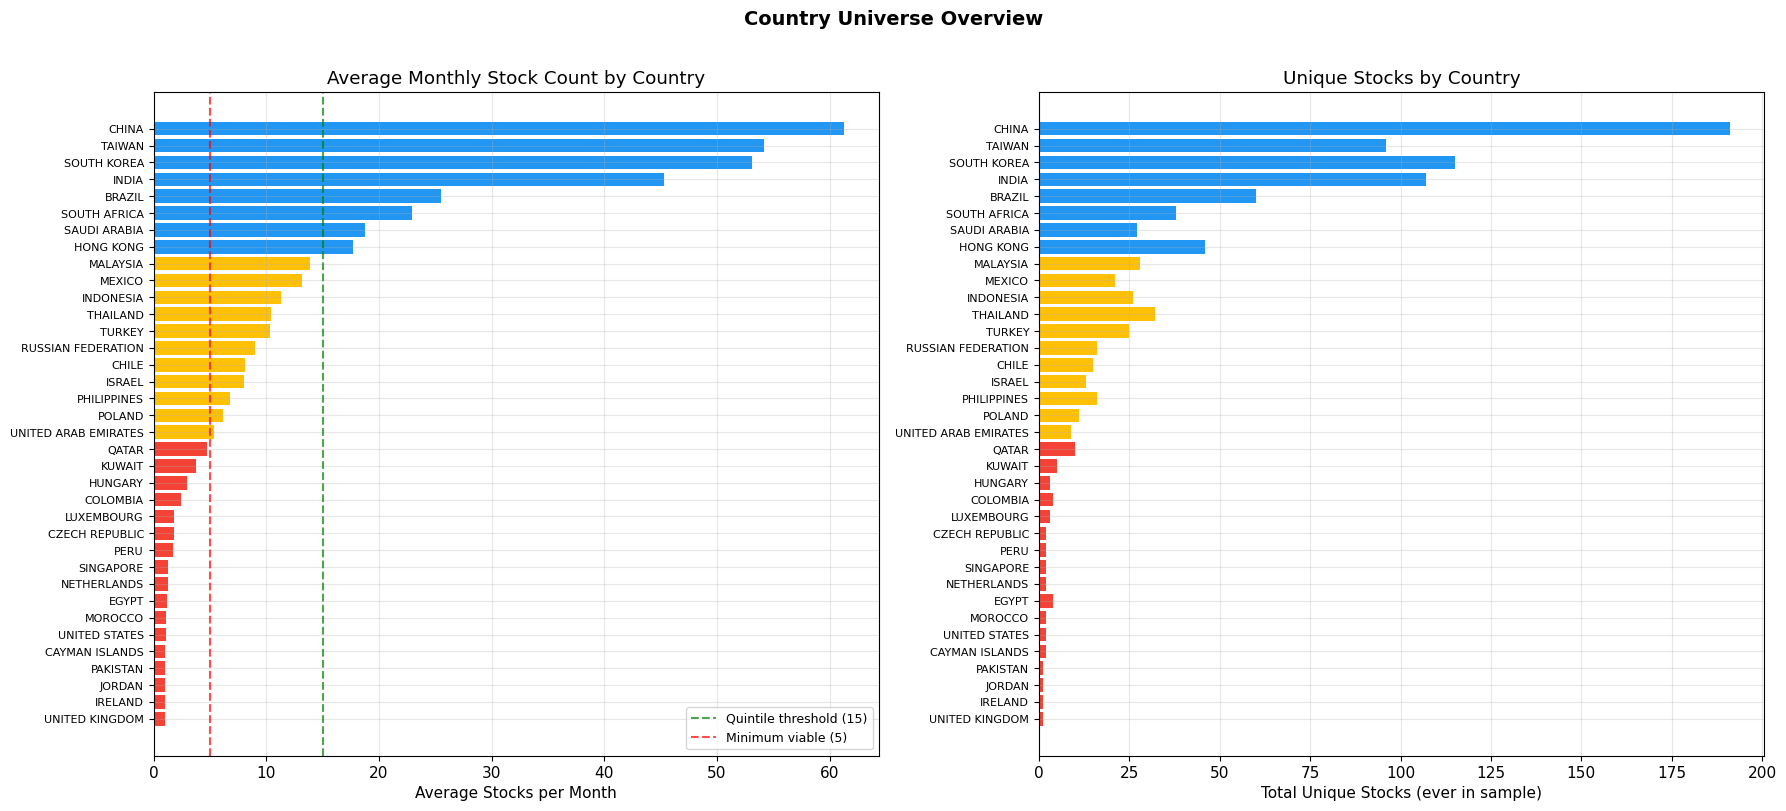

In [3]:
# Bar chart: average stocks per month by country
top_countries = ctry_summary.sort_values("avg_stocks_mo", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
colors = [
    "#2196F3" if v >= 15 else "#FFC107" if v >= 5 else "#F44336"
    for v in top_countries["avg_stocks_mo"]
]
ax.barh(range(len(top_countries)), top_countries["avg_stocks_mo"], color=colors)
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries.index, fontsize=8)
ax.set_xlabel("Average Stocks per Month")
ax.set_title("Average Monthly Stock Count by Country")
ax.invert_yaxis()
ax.axvline(15, color="green", ls="--", alpha=0.7, label="Quintile threshold (15)")
ax.axvline(5, color="red", ls="--", alpha=0.7, label="Minimum viable (5)")
ax.legend(fontsize=9)

ax = axes[1]
ax.barh(range(len(top_countries)), top_countries["unique_stocks"], color=colors)
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries.index, fontsize=8)
ax.set_xlabel("Total Unique Stocks (ever in sample)")
ax.set_title("Unique Stocks by Country")
ax.invert_yaxis()

plt.suptitle("Country Universe Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_country_stock_counts.pdf", bbox_inches="tight")
plt.show()

## 2. Monthly Stock Count Evolution by Country

This is the key chart: how does each country's stock count change month-by-month? We need to identify:
- Countries that enter/exit the sample
- Structural breaks (e.g., Saudi Arabia entering MSCI EM)
- Secular trends (growing vs shrinking coverage)

In [4]:
# Pivot: rows=month, cols=country, values=stock count
pivot = (
    monthly_counts.pivot(index="ym", columns="country", values="n_stocks")
    .fillna(0)
    .astype(int)
    .sort_index()
)

large = [c for c in pivot.columns if pivot[c].mean() >= 15]
medium = [c for c in pivot.columns if 5 <= pivot[c].mean() < 15]
small = [c for c in pivot.columns if pivot[c].mean() < 5]

print(f"Large countries (avg >= 15 stocks/mo): {len(large)}")
print(f"  {large}")
print(f"\nMedium countries (5-14 stocks/mo): {len(medium)}")
print(f"  {medium}")
print(f"\nSmall countries (<5 stocks/mo): {len(small)}")
print(f"  {small}")

Large countries (avg >= 15 stocks/mo): 7
  ['BRAZIL', 'CHINA', 'HONG KONG', 'INDIA', 'SOUTH AFRICA', 'SOUTH KOREA', 'TAIWAN']

Medium countries (5-14 stocks/mo): 9
  ['CHILE', 'INDONESIA', 'MALAYSIA', 'MEXICO', 'PHILIPPINES', 'POLAND', 'RUSSIAN FEDERATION', 'THAILAND', 'TURKEY']

Small countries (<5 stocks/mo): 20
  ['CAYMAN ISLANDS', 'COLOMBIA', 'CZECH REPUBLIC', 'EGYPT', 'HUNGARY', 'IRELAND', 'ISRAEL', 'JORDAN', 'KUWAIT', 'LUXEMBOURG', 'MOROCCO', 'NETHERLANDS', 'PAKISTAN', 'PERU', 'QATAR', 'SAUDI ARABIA', 'SINGAPORE', 'UNITED ARAB EMIRATES', 'UNITED KINGDOM', 'UNITED STATES']


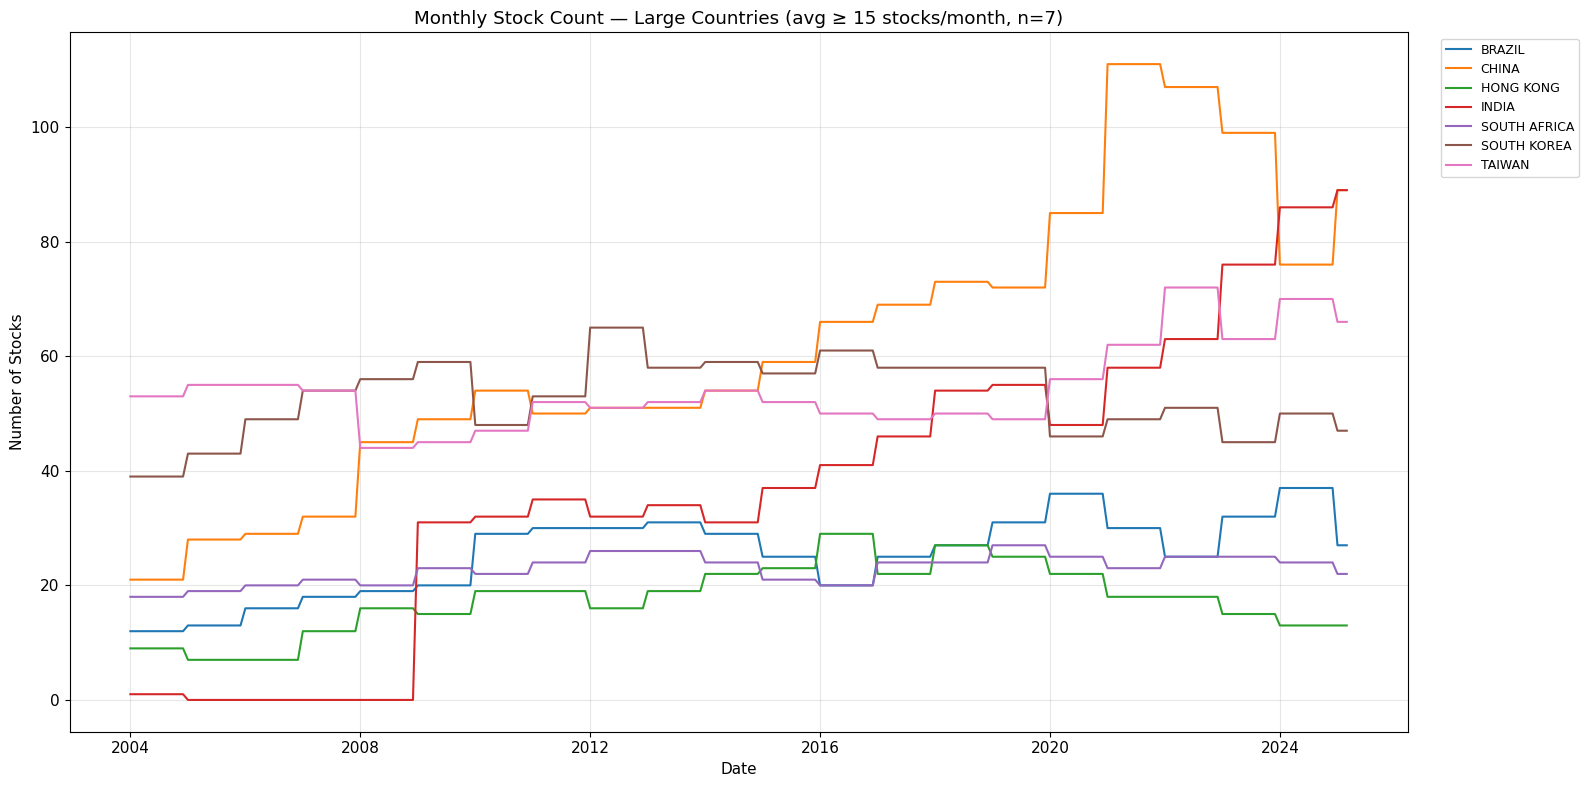

In [5]:
# Plot 1: Large countries (individual lines)
fig, ax = plt.subplots(figsize=(16, 8))
for c in sorted(large):
    ax.plot(pivot.index, pivot[c], label=c, linewidth=1.5)
ax.set_xlabel("Date")
ax.set_ylabel("Number of Stocks")
ax.set_title(
    f"Monthly Stock Count — Large Countries (avg ≥ 15 stocks/month, n={len(large)})"
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_large_countries_timeseries.pdf", bbox_inches="tight")
plt.show()

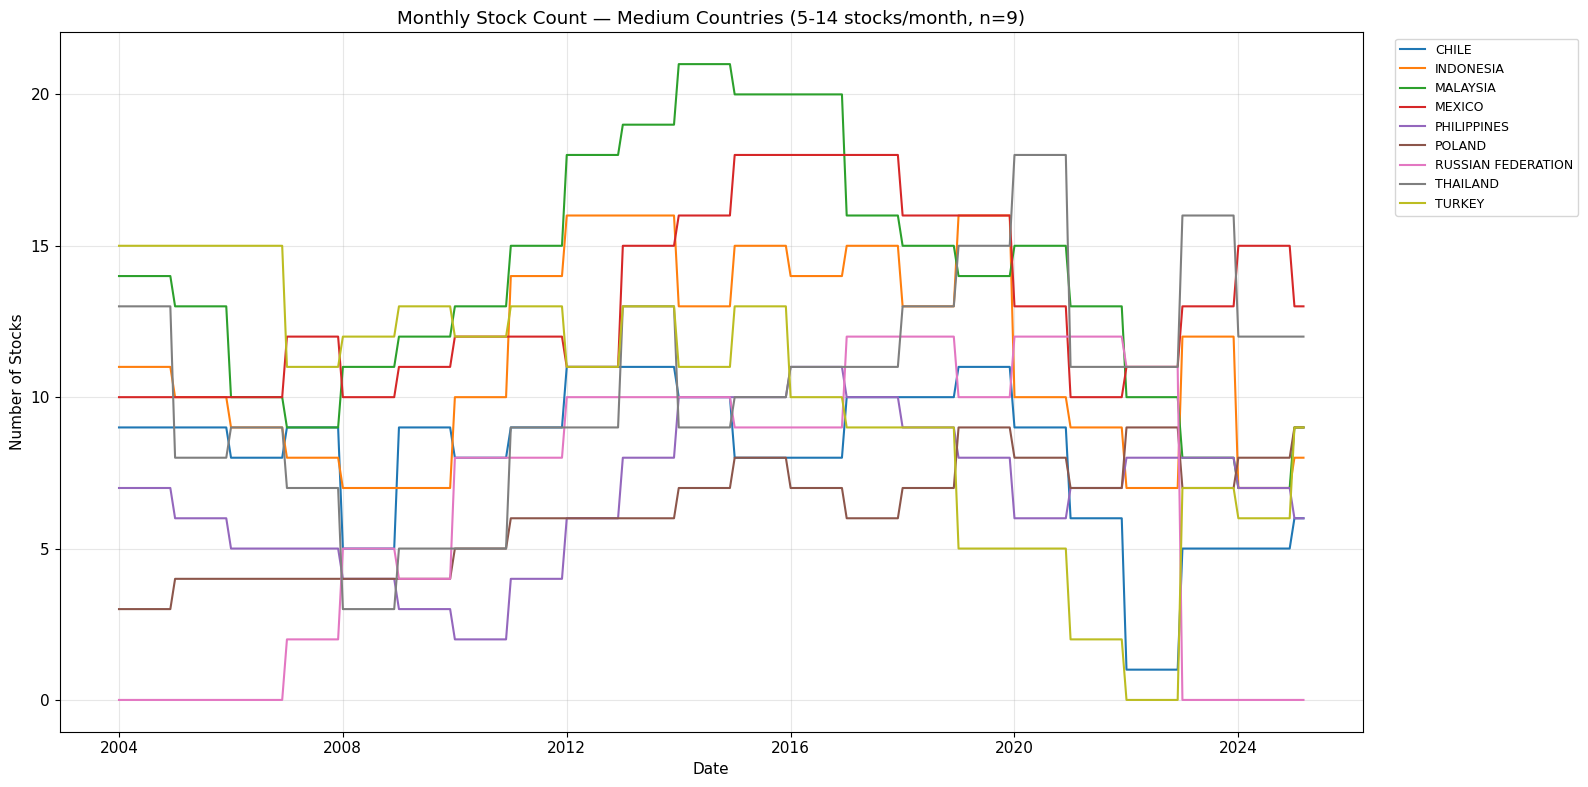

In [6]:
# Plot 2: Medium countries (individual lines)
fig, ax = plt.subplots(figsize=(16, 8))
for c in sorted(medium):
    ax.plot(pivot.index, pivot[c], label=c, linewidth=1.5)
ax.set_xlabel("Date")
ax.set_ylabel("Number of Stocks")
ax.set_title(
    f"Monthly Stock Count — Medium Countries (5-14 stocks/month, n={len(medium)})"
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_medium_countries_timeseries.pdf", bbox_inches="tight")
plt.show()

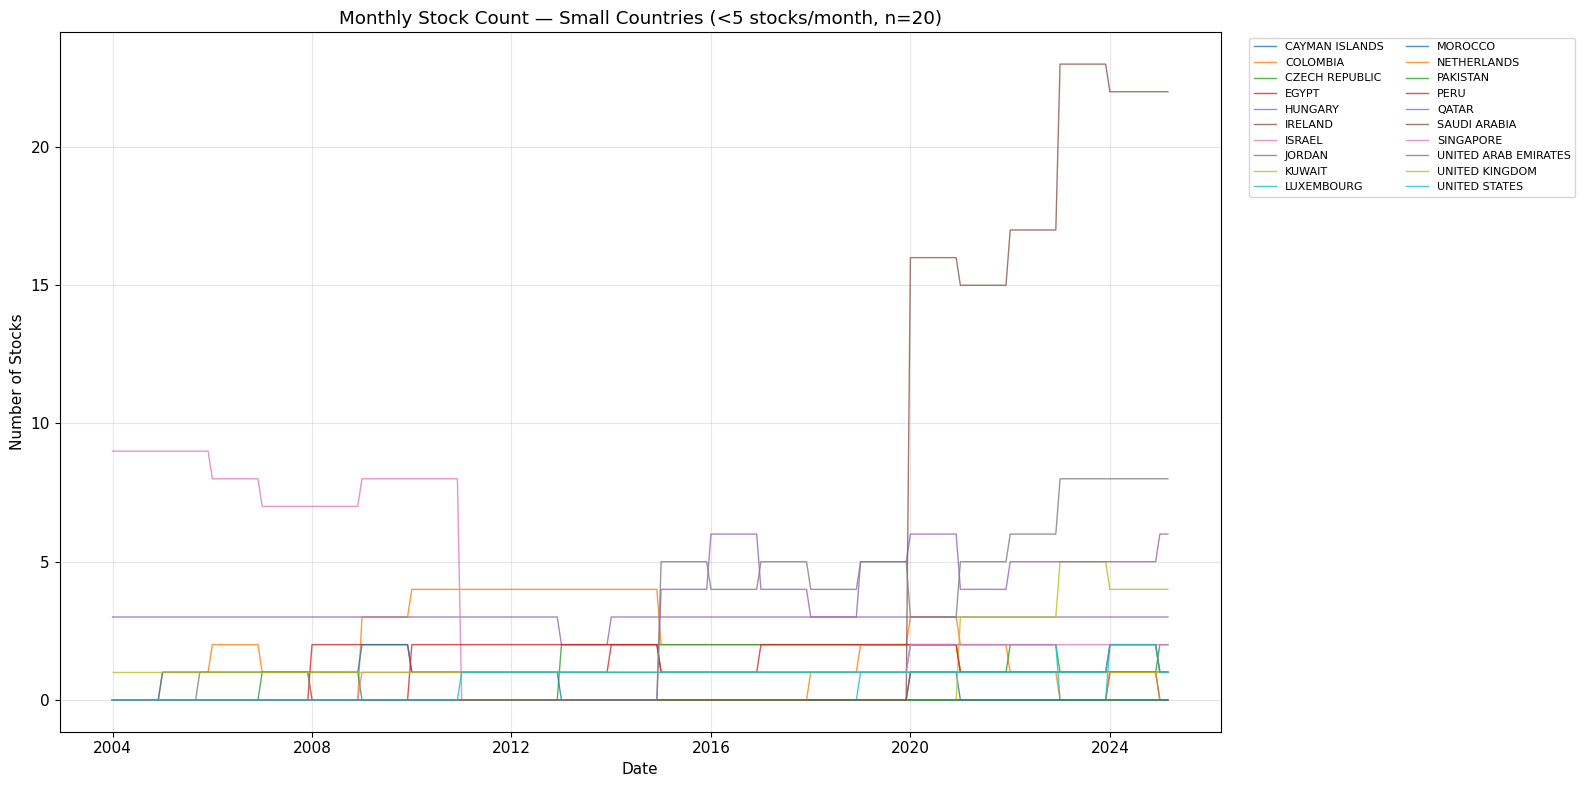

In [7]:
# Plot 3: Small countries (individual lines)
fig, ax = plt.subplots(figsize=(16, 8))
for c in sorted(small):
    ax.plot(pivot.index, pivot[c], label=c, linewidth=1.0, alpha=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Number of Stocks")
ax.set_title(
    f"Monthly Stock Count — Small Countries (<5 stocks/month, n={len(small)})"
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_small_countries_timeseries.pdf", bbox_inches="tight")
plt.show()

## 3. Country Coverage Heatmap

A heatmap showing stock count (month × country) gives a bird's-eye view of the full panel structure, including entry/exit events.

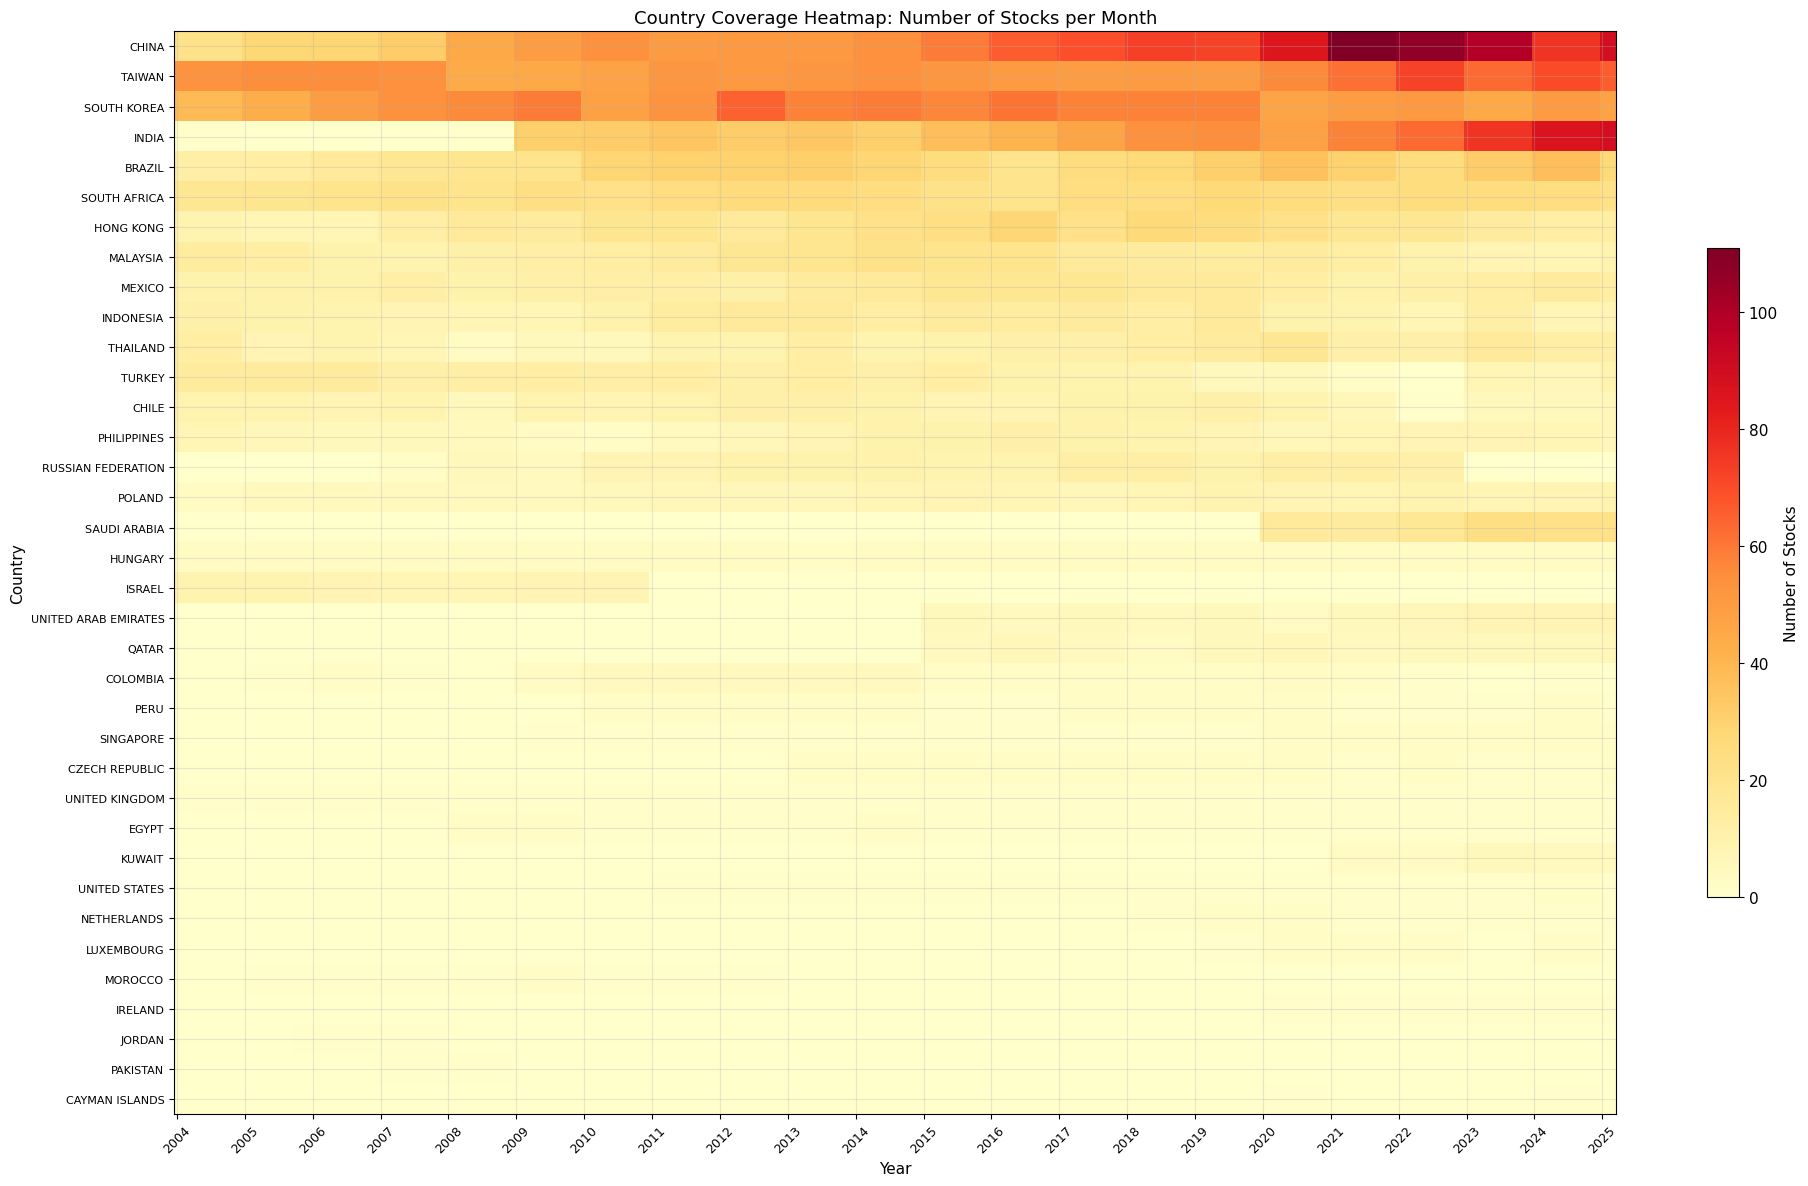

In [8]:
# Heatmap: country × time (sorted by average count)
order = pivot.mean().sort_values(ascending=False).index.tolist()
pivot_sorted = pivot[order]

fig, ax = plt.subplots(figsize=(20, 12))
im = ax.imshow(
    pivot_sorted.T.values,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=8)

tick_positions = list(range(0, len(pivot_sorted), 12))
tick_labels = [pivot_sorted.index[i].strftime("%Y") for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=9)

ax.set_xlabel("Year")
ax.set_ylabel("Country")
ax.set_title("Country Coverage Heatmap: Number of Stocks per Month", fontsize=13)
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label("Number of Stocks")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_country_coverage_heatmap.pdf", bbox_inches="tight")
plt.show()

## 4. Country Entry/Exit Analysis

Identify when each country first appears and last appears in the sample. This reveals MSCI EM index changes (e.g., Saudi Arabia inclusion, Russia removal).

In [9]:
# Entry/exit dates and coverage span
entry_exit = df.groupby("country")["ym"].agg(["min", "max", "count"])
entry_exit.columns = ["first_month", "last_month", "total_obs"]
entry_exit["months_with_stocks"] = pivot.gt(0).sum()
n_months_panel = len(pivot)
entry_exit["coverage_pct"] = (
    entry_exit["months_with_stocks"] / n_months_panel * 100
).round(1)
entry_exit = entry_exit.sort_values("first_month")

print("COUNTRY ENTRY/EXIT ANALYSIS")
print("=" * 90)
for name, row in entry_exit.iterrows():
    print(
        f"{name:30s}  First: {row['first_month']:%Y-%m}  Last: {row['last_month']:%Y-%m}  "
        f"Coverage: {row['coverage_pct']:5.1f}%  "
        f"Months: {row['months_with_stocks']:3d}/{n_months_panel}"
    )

COUNTRY ENTRY/EXIT ANALYSIS
BRAZIL                          First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
TURKEY                          First: 2004-01  Last: 2025-03  Coverage:  95.3%  Months: 243/255
THAILAND                        First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
TAIWAN                          First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
SOUTH KOREA                     First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
SOUTH AFRICA                    First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
POLAND                          First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
PHILIPPINES                     First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
UNITED KINGDOM                  First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
MALAYSIA                        First: 2004-01  Last: 2025-03  Coverage: 100.0%  Months: 255/255
IS

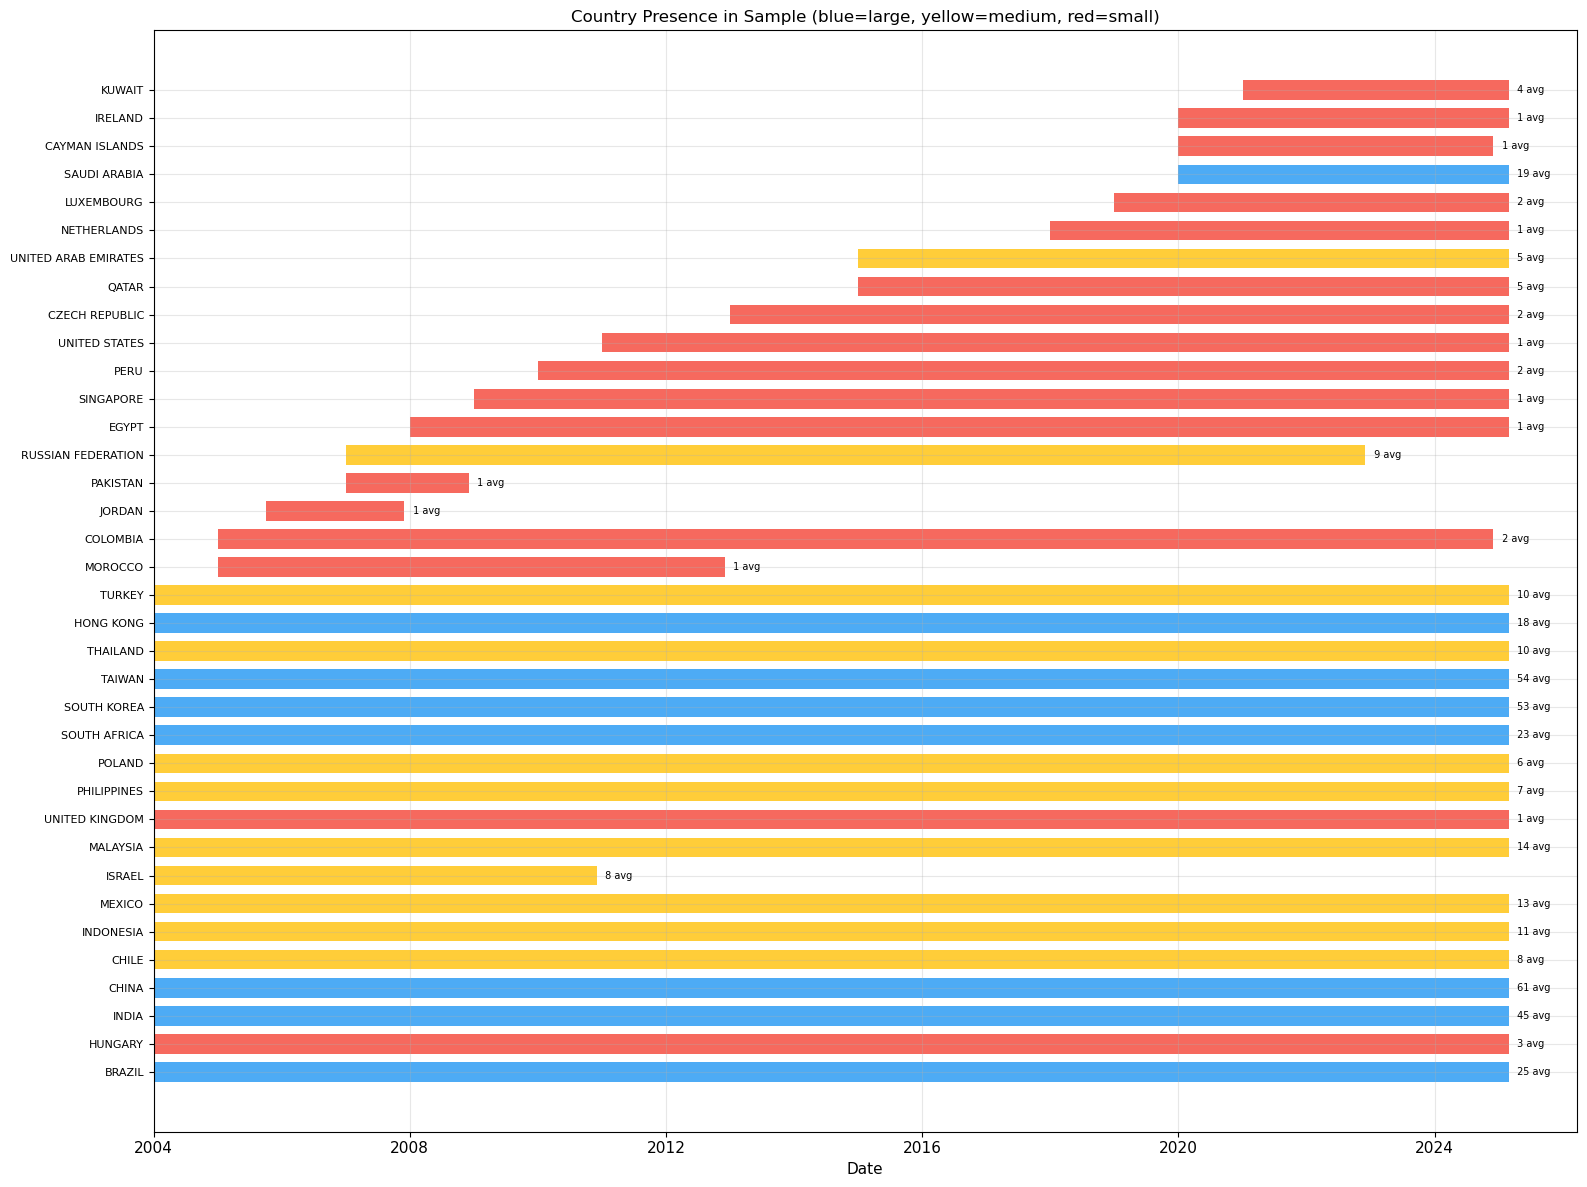

In [10]:
# Gantt-style chart of country presence
order_gantt = entry_exit.sort_values("first_month", ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(16, 12))
for i, c in enumerate(order_gantt):
    months_present = pivot.index[pivot[c] > 0]
    if len(months_present) > 0:
        avg_n = pivot.loc[months_present, c].mean()
        color = "#2196F3" if avg_n >= 15 else "#FFC107" if avg_n >= 5 else "#F44336"
        ax.barh(
            i,
            width=(months_present[-1] - months_present[0]).days,
            left=months_present[0],
            height=0.7,
            color=color,
            alpha=0.8,
        )
        ax.text(
            months_present[-1] + pd.Timedelta(days=30),
            i,
            f" {avg_n:.0f} avg",
            va="center",
            fontsize=7,
        )

ax.set_yticks(range(len(order_gantt)))
ax.set_yticklabels(order_gantt, fontsize=8)
ax.set_xlabel("Date")
ax.set_title(
    "Country Presence in Sample (blue=large, yellow=medium, red=small)", fontsize=12
)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_country_gantt.pdf", bbox_inches="tight")
plt.show()

## 5. Feasibility for Factor Portfolios: Minimum Stock Count Analysis

For cross-sectional factor selection (top quintile), we need at least **~15 stocks** per country-month to select 3+ stocks. For tercile, we need **~10**. Countries with fewer stocks cannot support meaningful factor sorting.

We compute: what fraction of months does each country have ≥ N stocks?

In [11]:
# For each country, % of months with >= N stocks
thresholds = [5, 10, 15, 20, 30]
feasibility = pd.DataFrame(index=pivot.columns)

for t in thresholds:
    feasibility[f">={t}"] = (pivot >= t).mean().round(3) * 100

feasibility["avg_stocks"] = pivot.mean().round(1)
feasibility = feasibility.sort_values("avg_stocks", ascending=False)

print("FEASIBILITY: % of months with >= N stocks per country")
print("=" * 80)
print(feasibility.to_string())

print("\n" + "=" * 80)
print("SUMMARY FOR FACTOR PORTFOLIO CONSTRUCTION")
print("=" * 80)
for t in thresholds:
    col = f">={t}"
    viable = feasibility[feasibility[col] >= 80].index.tolist()
    print(f"\nCountries with >= {t} stocks in >= 80% of months: {len(viable)}")
    if len(viable) <= 20:
        print(f"  {viable}")

FEASIBILITY: % of months with >= N stocks per country
                        >=5   >=10   >=15   >=20   >=30  avg_stocks
country                                                            
CHINA                 100.0  100.0  100.0  100.0   85.9        61.3
TAIWAN                100.0  100.0  100.0  100.0  100.0        54.2
SOUTH KOREA           100.0  100.0  100.0  100.0  100.0        53.1
INDIA                  76.5   76.5   76.5   76.5   76.5        36.8
BRAZIL                100.0  100.0   90.6   76.5   37.6        25.5
SOUTH AFRICA          100.0  100.0  100.0   90.6    0.0        22.9
HONG KONG             100.0   85.9   75.3   32.9    0.0        17.7
MALAYSIA              100.0   84.7   42.4   14.1    0.0        13.9
MEXICO                100.0  100.0   37.6    0.0    0.0        13.2
INDONESIA             100.0   65.9   23.5    0.0    0.0        11.3
THAILAND               95.3   57.6   14.1    0.0    0.0        10.4
TURKEY                 90.6   61.2   14.1    0.0    0.0       

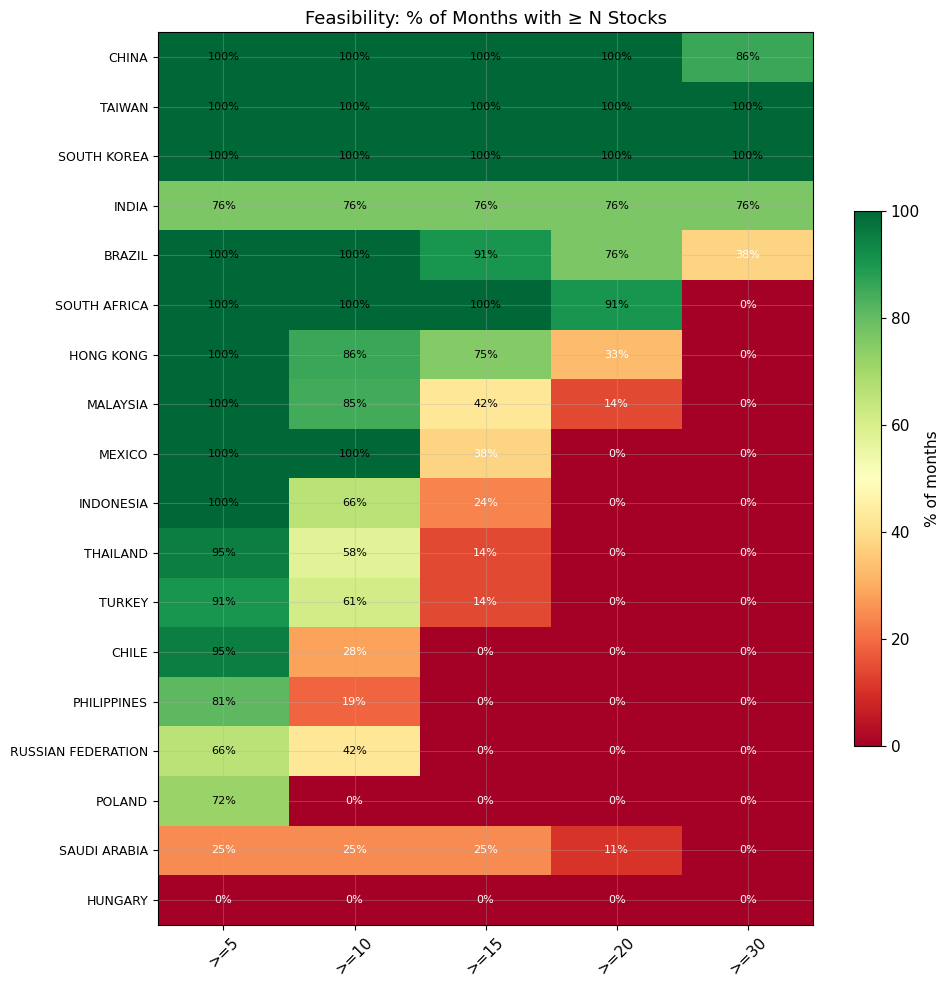

In [12]:
# Heatmap of feasibility
feas_plot = feasibility.drop("avg_stocks", axis=1)
feas_plot = feas_plot[feasibility["avg_stocks"] >= 3]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(feas_plot.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(feas_plot.columns)))
ax.set_xticklabels(feas_plot.columns, rotation=45)
ax.set_yticks(range(len(feas_plot.index)))
ax.set_yticklabels(feas_plot.index, fontsize=9)

for i in range(len(feas_plot.index)):
    for j in range(len(feas_plot.columns)):
        val = feas_plot.iloc[i, j]
        color = "white" if val < 40 else "black"
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=8, color=color)

ax.set_title("Feasibility: % of Months with ≥ N Stocks", fontsize=13)
plt.colorbar(im, ax=ax, shrink=0.6, label="% of months")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_country_feasibility_heatmap.pdf", bbox_inches="tight")
plt.show()

## 6. Country vs. Industry: Structural Comparison

Compare the country and industry dimensions as potential grouping variables for factor portfolios.

In [13]:
# Side-by-side comparison: industry vs country stock counts
ind_monthly = (
    df.groupby(["ym", "industry"])["ric"].nunique().reset_index(name="n_stocks")
)
ind_avg = ind_monthly.groupby("industry")["n_stocks"].agg(["mean", "min", "max"]).round(1)
ind_avg.columns = ["avg", "min", "max"]
ind_avg = ind_avg.sort_values("avg", ascending=False)

ctry_avg = monthly_counts.groupby("country")["n_stocks"].agg(["mean", "min", "max"]).round(1)
ctry_avg.columns = ["avg", "min", "max"]
ctry_avg = ctry_avg.sort_values("avg", ascending=False)

n_ind = ind_avg.shape[0]
n_ctry = df["country"].nunique()

print("DIMENSION COMPARISON: INDUSTRY vs COUNTRY")
print("=" * 70)
print(f'{"":<35s} {"INDUSTRY":>15s} {"COUNTRY":>15s}')
print("-" * 70)
print(f'{"Number of groups":<35s} {n_ind:>15d} {n_ctry:>15d}')
print(
    f'{"Groups with avg >= 15 stocks/mo":<35s} '
    f'{(ind_avg["avg"] >= 15).sum():>15d} {(ctry_avg["avg"] >= 15).sum():>15d}'
)
print(
    f'{"Groups with avg >= 10 stocks/mo":<35s} '
    f'{(ind_avg["avg"] >= 10).sum():>15d} {(ctry_avg["avg"] >= 10).sum():>15d}'
)
print(
    f'{"Groups with avg >= 5 stocks/mo":<35s} '
    f'{(ind_avg["avg"] >= 5).sum():>15d} {(ctry_avg["avg"] >= 5).sum():>15d}'
)
print(
    f'{"Avg stocks in largest group":<35s} '
    f'{ind_avg["avg"].max():>15.1f} {ctry_avg["avg"].max():>15.1f}'
)
print(
    f'{"Avg stocks in smallest group":<35s} '
    f'{ind_avg["avg"].min():>15.1f} {ctry_avg["avg"].min():>15.1f}'
)
print(
    f'{"Median group size":<35s} '
    f'{ind_avg["avg"].median():>15.1f} {ctry_avg["avg"].median():>15.1f}'
)

print(f'\n{"":<35s} {"Min stocks":>15s} {"Max stocks":>15s}')
print("-" * 70)
print(
    f'{"Industry (all groups)":<35s} '
    f'{ind_avg["min"].min():>15.0f} {ind_avg["max"].max():>15.0f}'
)
print(
    f'{"Country (top 15 by avg)":<35s} '
    f'{ctry_avg.head(15)["min"].min():>15.0f} {ctry_avg.head(15)["max"].max():>15.0f}'
)

DIMENSION COMPARISON: INDUSTRY vs COUNTRY
                                           INDUSTRY         COUNTRY
----------------------------------------------------------------------
Number of groups                                 11              36
Groups with avg >= 15 stocks/mo                   9               8
Groups with avg >= 10 stocks/mo                  11              13
Groups with avg >= 5 stocks/mo                   11              19
Avg stocks in largest group                    87.6            61.3
Avg stocks in smallest group                   13.5             1.0
Median group size                              36.0             5.8

                                         Min stocks      Max stocks
----------------------------------------------------------------------
Industry (all groups)                             1             127
Country (top 15 by avg)                           1             111


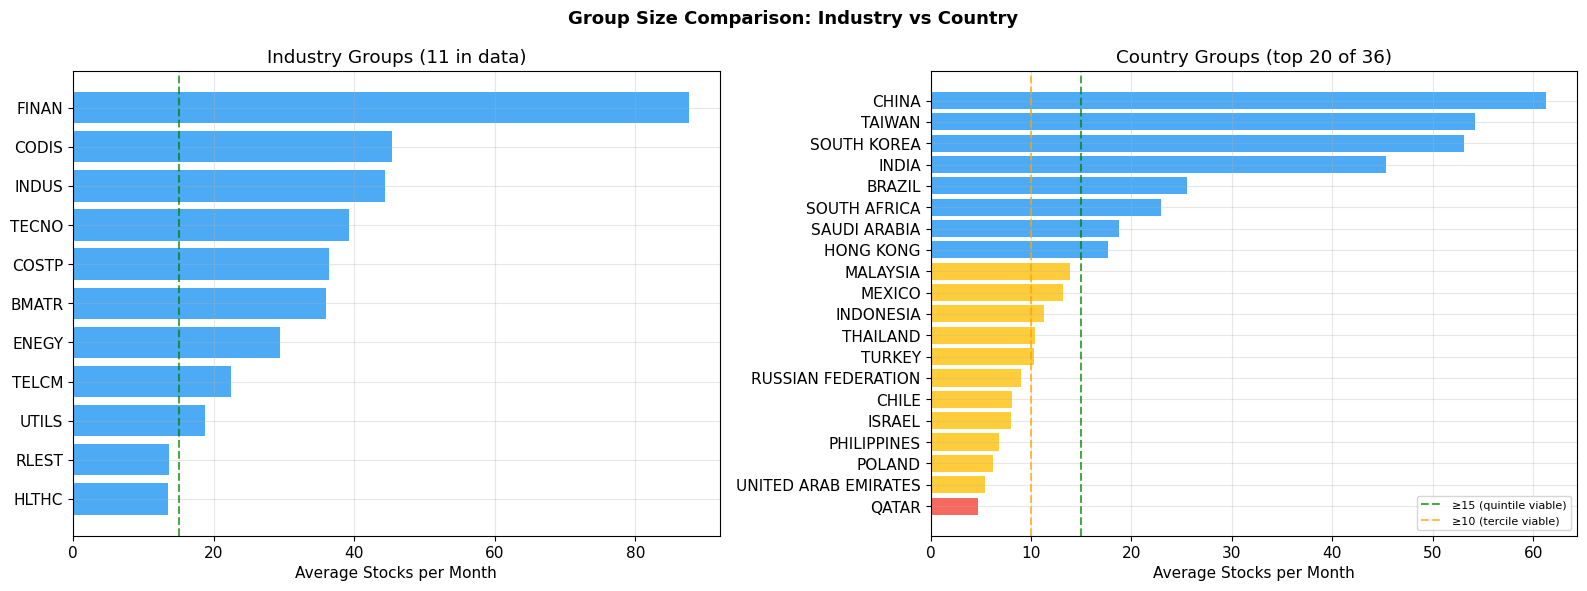

In [14]:
# Visual: distribution of group sizes — industry vs country
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.barh(range(len(ind_avg)), ind_avg["avg"], color="#2196F3", alpha=0.8)
ax.set_yticks(range(len(ind_avg)))
ax.set_yticklabels(ind_avg.index)
ax.set_xlabel("Average Stocks per Month")
ax.set_title(f"Industry Groups ({n_ind} in data)")
ax.invert_yaxis()
ax.axvline(15, color="green", ls="--", alpha=0.7)

ax = axes[1]
top_ctry = ctry_avg.head(20)
colors = [
    "#2196F3" if v >= 15 else "#FFC107" if v >= 5 else "#F44336" for v in top_ctry["avg"]
]
ax.barh(range(len(top_ctry)), top_ctry["avg"], color=colors, alpha=0.8)
ax.set_yticks(range(len(top_ctry)))
ax.set_yticklabels(top_ctry.index)
ax.set_xlabel("Average Stocks per Month")
ax.set_title(f"Country Groups (top 20 of {n_ctry})")
ax.invert_yaxis()
ax.axvline(15, color="green", ls="--", alpha=0.7, label="≥15 (quintile viable)")
ax.axvline(10, color="orange", ls="--", alpha=0.7, label="≥10 (tercile viable)")
ax.legend(fontsize=8)

plt.suptitle("Group Size Comparison: Industry vs Country", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_industry_vs_country_sizes.pdf", bbox_inches="tight")
plt.show()

## 7. Country-Level Return Statistics

Compute equal-weighted country-level returns and basic risk/return statistics.

In [15]:
# Equal-weighted returns per country per month
ctry_ret = df.groupby(["ym", "country"])["mret_bbg"].mean().reset_index()
ctry_ret_pivot = ctry_ret.pivot(index="ym", columns="country", values="mret_bbg")

min_months = 60
valid_countries = ctry_ret_pivot.columns[ctry_ret_pivot.notna().sum() >= min_months]

stats = pd.DataFrame(index=valid_countries)
for c in valid_countries:
    s = ctry_ret_pivot[c].dropna()
    stats.loc[c, "ann_ret"] = s.mean() * 12 * 100
    stats.loc[c, "ann_vol"] = s.std() * np.sqrt(12) * 100
    stats.loc[c, "sharpe"] = (
        (s.mean() / s.std()) * np.sqrt(12) if s.std() > 0 else 0
    )
    stats.loc[c, "n_months"] = len(s)
    stats.loc[c, "avg_stocks"] = pivot[c].loc[pivot[c] > 0].mean()

stats = stats.sort_values("sharpe", ascending=False)
stats["ann_ret"] = stats["ann_ret"].round(1)
stats["ann_vol"] = stats["ann_vol"].round(1)
stats["sharpe"] = stats["sharpe"].round(3)

print("COUNTRY EQUAL-WEIGHTED RETURN STATISTICS (min 60 months)")
print("=" * 80)
print(stats.to_string())

COUNTRY EQUAL-WEIGHTED RETURN STATISTICS (min 60 months)
                      ann_ret  ann_vol  sharpe  n_months  avg_stocks
country                                                             
ISRAEL                   20.6     22.6   0.910      84.0    8.000000
IRELAND                  43.6     70.0   0.623      63.0    1.000000
MEXICO                   14.8     24.6   0.603     255.0   13.188235
INDIA                    14.5     25.0   0.581     207.0   45.347826
UNITED ARAB EMIRATES     11.4     20.4   0.557     123.0    5.365854
MOROCCO                  11.5     21.1   0.546      96.0    1.125000
SAUDI ARABIA              9.1     16.9   0.540      63.0   18.761905
CZECH REPUBLIC           12.7     24.1   0.525     147.0    1.755102
TAIWAN                   10.0     20.5   0.488     255.0   54.188235
SINGAPORE                12.6     26.3   0.480     195.0    1.323077
PHILIPPINES              11.1     23.7   0.470     255.0    6.847059
POLAND                   15.7     34.0   0.463

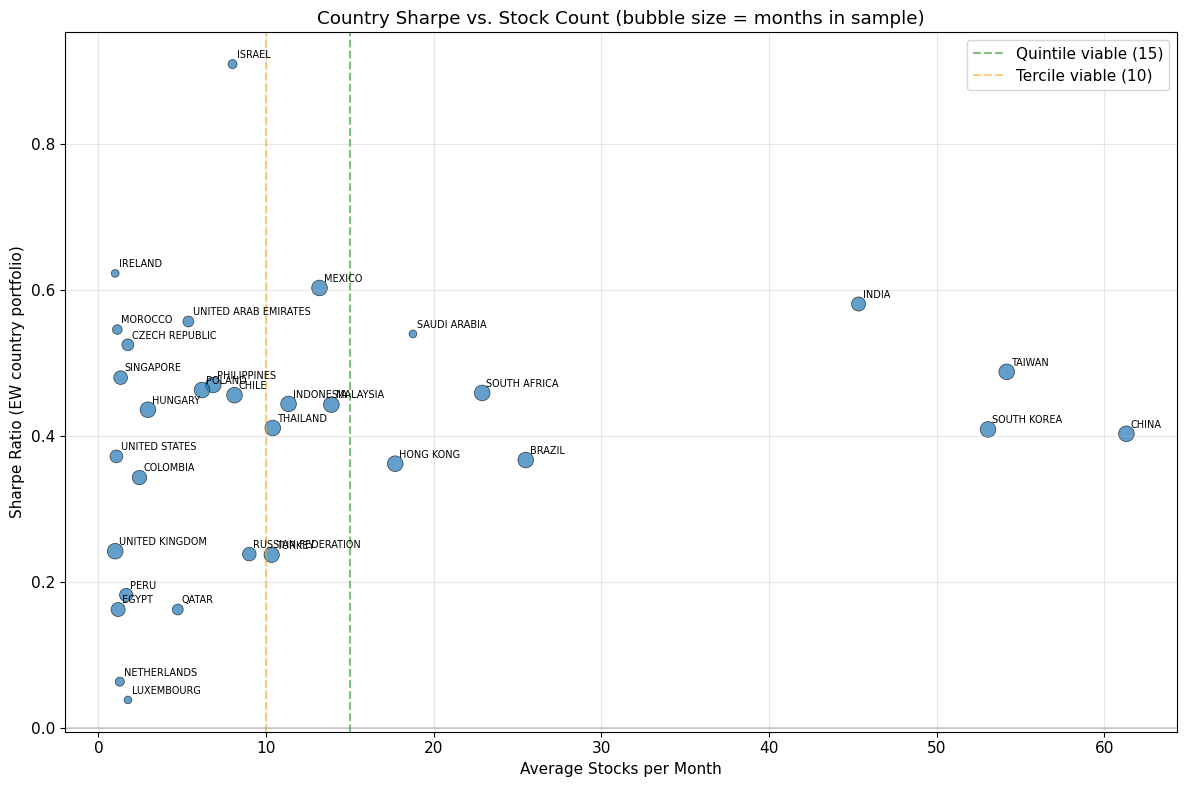

In [16]:
# Scatter: Sharpe vs avg stocks per month
fig, ax = plt.subplots(figsize=(12, 8))
scatter_data = stats[stats["avg_stocks"] > 0].copy()
ax.scatter(
    scatter_data["avg_stocks"],
    scatter_data["sharpe"],
    s=scatter_data["n_months"] / 2,
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5,
)

for idx, row in scatter_data.iterrows():
    ax.annotate(
        idx,
        (row["avg_stocks"], row["sharpe"]),
        fontsize=7,
        ha="left",
        va="bottom",
        xytext=(3, 3),
        textcoords="offset points",
    )

ax.axvline(15, color="green", ls="--", alpha=0.5, label="Quintile viable (15)")
ax.axvline(10, color="orange", ls="--", alpha=0.5, label="Tercile viable (10)")
ax.axhline(0, color="grey", ls="-", alpha=0.3)
ax.set_xlabel("Average Stocks per Month")
ax.set_ylabel("Sharpe Ratio (EW country portfolio)")
ax.set_title("Country Sharpe vs. Stock Count (bubble size = months in sample)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_country_sharpe_vs_size.pdf", bbox_inches="tight")
plt.show()

## 8. Country Cross-Correlation Analysis

How correlated are country-level EW returns? Lower correlation = better diversification potential for a multi-country portfolio.

In [17]:
# Correlation matrix: countries with sufficient depth and history
viable_for_corr = [
    c
    for c in valid_countries
    if stats.loc[c, "avg_stocks"] >= 10 and stats.loc[c, "n_months"] >= 120
]
corr_data = ctry_ret_pivot[viable_for_corr].dropna(how="all")
corr_mat = corr_data.corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
upper_vals = corr_mat.values[mask]
print(
    f"Average pairwise correlation (n={len(viable_for_corr)} countries): "
    f"{upper_vals.mean():.3f}"
)
print(
    f"Median: {np.median(upper_vals):.3f}, Min: {upper_vals.min():.3f}, "
    f"Max: {upper_vals.max():.3f}"
)

ind_ret = df.groupby(["ym", "industry"])["mret_bbg"].mean().reset_index()
ind_ret_pivot = ind_ret.pivot(index="ym", columns="industry", values="mret_bbg")
ind_corr = ind_ret_pivot.corr()
ind_mask = np.triu(np.ones_like(ind_corr, dtype=bool), k=1)
ind_upper = ind_corr.values[ind_mask]
print(
    f"\nFor comparison — Industry EW correlation (n={ind_corr.shape[0]}): "
    f"{ind_upper.mean():.3f}"
)
print(
    f"Median: {np.median(ind_upper):.3f}, Min: {ind_upper.min():.3f}, "
    f"Max: {ind_upper.max():.3f}"
)

Average pairwise correlation (n=12 countries): 0.578
Median: 0.579, Min: 0.389, Max: 0.930

For comparison — Industry EW correlation (n=11): 0.761
Median: 0.778, Min: 0.580, Max: 0.897


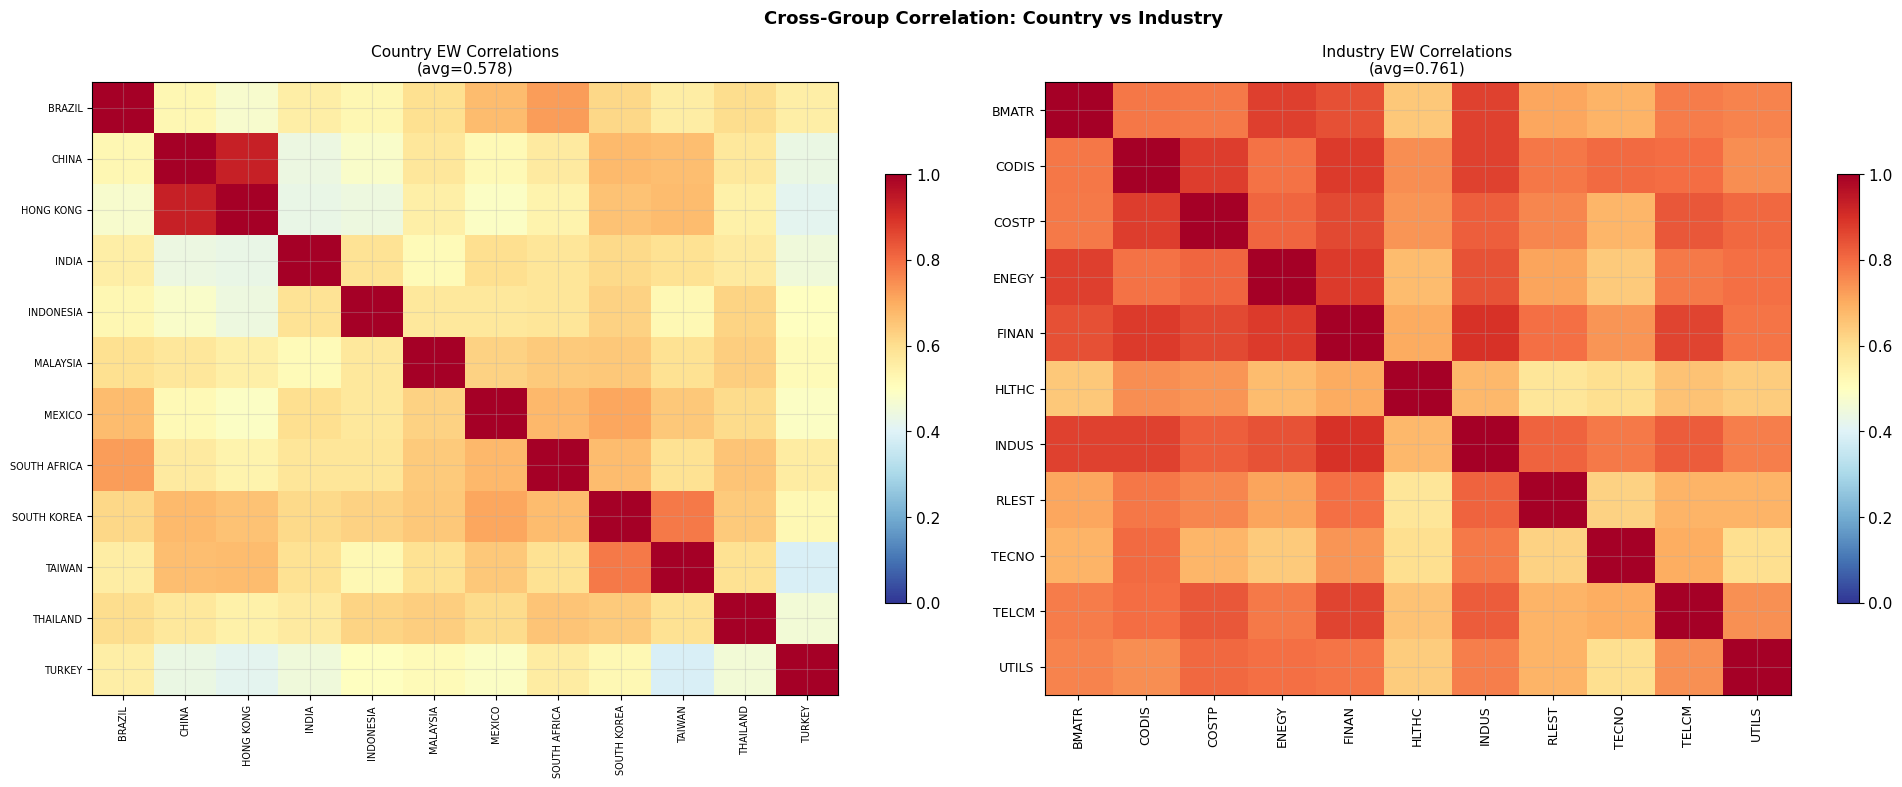

In [18]:
# Correlation heatmaps (country vs industry)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ax = axes[0]
im = ax.imshow(corr_mat.values, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_mat)))
ax.set_xticklabels(corr_mat.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr_mat)))
ax.set_yticklabels(corr_mat.index, fontsize=7)
ax.set_title(f"Country EW Correlations\n(avg={upper_vals.mean():.3f})", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.7)

ax = axes[1]
im2 = ax.imshow(ind_corr.values, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(ind_corr)))
ax.set_xticklabels(ind_corr.columns, rotation=90, fontsize=9)
ax.set_yticks(range(len(ind_corr)))
ax.set_yticklabels(ind_corr.index, fontsize=9)
ax.set_title(f"Industry EW Correlations\n(avg={ind_upper.mean():.3f})", fontsize=11)
plt.colorbar(im2, ax=ax, shrink=0.7)

plt.suptitle("Cross-Group Correlation: Country vs Industry", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_country_vs_industry_correlation.pdf", bbox_inches="tight")
plt.show()

## 9. Country × Industry Cross-Tabulation

How are stocks distributed across the country × industry matrix? This helps understand whether country portfolios would have industry concentration issues.

COUNTRY × INDUSTRY: Unique Stocks (top 15 countries)
industry            BMATR  CODIS  COSTP  ENEGY  FINAN  HLTHC  INDUS  RLEST  TECNO  TELCM  UTILS
country                                                                                        
CHINA                   8     38     16     10     33     15     23     13     22      7      6
TAIWAN                  3     10      2      1     16      0     12      0     47      5      0
SOUTH KOREA             7     28      6      5     18     10     28      0      7      5      1
INDIA                  12     13     11      8     19      9     13      2     10      4      6
BRAZIL                  6     10      6      6     11      4      3      3      1      3      7
SOUTH AFRICA            9      4      7      1      9      2      1      1      0      4      0
SAUDI ARABIA            6      2      2      1      9      2      0      0      1      2      2
HONG KONG               3      6      4      2      3      4      5      8      2  

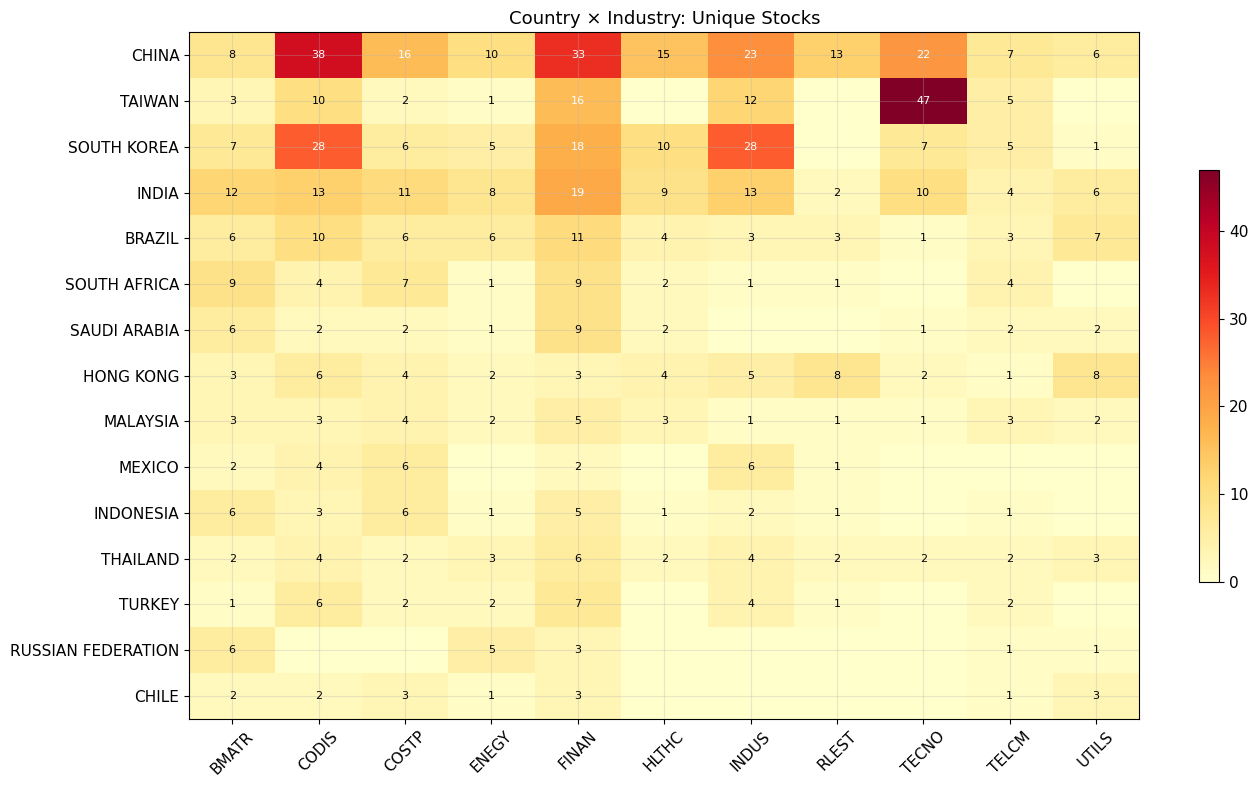

In [19]:
# Average stocks per country × industry (top 15 countries by avg size)
top_ctry_list = ctry_avg.head(15).index.tolist()
sub = df[df["country"].isin(top_ctry_list)]
cross = sub.groupby(["country", "industry"])["ric"].nunique().reset_index(
    name="unique_stocks"
)
cross_pivot = (
    cross.pivot(index="country", columns="industry", values="unique_stocks")
    .fillna(0)
    .astype(int)
)
cross_pivot = cross_pivot.loc[top_ctry_list]

print("COUNTRY × INDUSTRY: Unique Stocks (top 15 countries)")
print("=" * 120)
print(cross_pivot.to_string())

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(cross_pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(cross_pivot.columns)))
ax.set_xticklabels(cross_pivot.columns, rotation=45)
ax.set_yticks(range(len(cross_pivot.index)))
ax.set_yticklabels(cross_pivot.index)

for i in range(len(cross_pivot.index)):
    for j in range(len(cross_pivot.columns)):
        val = cross_pivot.iloc[i, j]
        if val > 0:
            color = "white" if val > 15 else "black"
            ax.text(j, i, str(val), ha="center", va="center", fontsize=8, color=color)

ax.set_title("Country × Industry: Unique Stocks", fontsize=13)
plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb14_country_industry_cross.pdf", bbox_inches="tight")
plt.show()

## 10. Summary and Implications for Country Factor Portfolios

In [20]:
print("=" * 80)
print("SUMMARY: COUNTRY UNIVERSE EXPLORATION")
print("=" * 80)

print("\nA. UNIVERSE SIZE")
print(f'   Total countries in data: {df["country"].nunique()}')
print(f'   Total unique stocks: {df["ric"].nunique()}')
print(f"   Total observations: {len(df):,}")

n_large = len(large)
n_medium = len(medium)
n_small = len(small)
print("\nB. COUNTRY SIZE CLASSIFICATION")
print(f"   Large (avg >= 15 stocks/mo):  {n_large} countries")
for c in sorted(large):
    print(f"      {c}: {pivot[c].mean():.1f} avg stocks")
print(f"   Medium (5-14 stocks/mo):      {n_medium} countries")
for c in sorted(medium):
    print(f"      {c}: {pivot[c].mean():.1f} avg stocks")
print(f"   Small (<5 stocks/mo):         {n_small} countries (not viable for factor selection)")

viable_quintile = [c for c in pivot.columns if pivot[c].mean() >= 15]
viable_tercile = [c for c in pivot.columns if 10 <= pivot[c].mean() < 15]

print("\nC. FEASIBILITY FOR FACTOR PORTFOLIOS")
print(
    f"   Quintile selection (top 20%, need ~15+ stocks): {len(viable_quintile)} countries"
)
print(
    f"   Tercile selection (top 33%, need ~10+ stocks):  "
    f"{len(viable_quintile) + len(viable_tercile)} countries"
)
print(
    f"   Compare: industry pipeline uses {n_ind} groups "
    f"(smallest group avg: {ind_avg['avg'].min():.1f} stocks/mo)"
)

print("\nD. CORRELATION STRUCTURE")
print(f"   Avg country EW pairwise correlation: {upper_vals.mean():.3f}")
print(f"   Avg industry EW pairwise correlation: {ind_upper.mean():.3f}")
if upper_vals.mean() < ind_upper.mean():
    print("   → Country groups have LOWER correlation → better diversification potential")
else:
    print("   → Industry groups have LOWER correlation → better diversification potential")

print("\nE. KEY STRUCTURAL DIFFERENCES FROM INDUSTRY PIPELINE")
print(f'   1. More groups ({df["country"].nunique()} vs {n_ind}) but many too small for factor sorting')
print(
    f"   2. Country sizes are more dispersed "
    f"(1-{ctry_avg['avg'].max():.0f} avg stocks vs "
    f"{ind_avg['avg'].min():.0f}-{ind_avg['avg'].max():.0f} for industries)"
)
print("   3. Some countries enter/exit sample (e.g., MSCI reclassifications)")
print("   4. Country portfolios may have industry concentration (e.g., Saudi = mostly FINAN)")

print("\nF. RECOMMENDATION")
print(f"   Use top ~{len(viable_quintile)} countries for quintile selection")
print(f"   Add ~{len(viable_tercile)} countries with tercile selection")
print('   Group remaining small countries into "Other EM" or drop them')

stats.to_csv(f"{CSV_DIR}/nb14_country_return_stats.csv")
feasibility.to_csv(f"{CSV_DIR}/nb14_country_feasibility.csv")
print("\nSaved: nb14_country_return_stats.csv, nb14_country_feasibility.csv")

SUMMARY: COUNTRY UNIVERSE EXPLORATION

A. UNIVERSE SIZE
   Total countries in data: 36
   Total unique stocks: 953
   Total observations: 98,742

B. COUNTRY SIZE CLASSIFICATION
   Large (avg >= 15 stocks/mo):  7 countries
      BRAZIL: 25.5 avg stocks
      CHINA: 61.3 avg stocks
      HONG KONG: 17.7 avg stocks
      INDIA: 36.8 avg stocks
      SOUTH AFRICA: 22.9 avg stocks
      SOUTH KOREA: 53.1 avg stocks
      TAIWAN: 54.2 avg stocks
   Medium (5-14 stocks/mo):      9 countries
      CHILE: 8.1 avg stocks
      INDONESIA: 11.3 avg stocks
      MALAYSIA: 13.9 avg stocks
      MEXICO: 13.2 avg stocks
      PHILIPPINES: 6.8 avg stocks
      POLAND: 6.2 avg stocks
      RUSSIAN FEDERATION: 6.8 avg stocks
      THAILAND: 10.4 avg stocks
      TURKEY: 9.8 avg stocks
   Small (<5 stocks/mo):         20 countries (not viable for factor selection)

C. FEASIBILITY FOR FACTOR PORTFOLIOS
   Quintile selection (top 20%, need ~15+ stocks): 7 countries
   Tercile selection (top 33%, need ~10+ s